# LSTM Autoencoder

- An LSTM Autoencoder is an autoencoder made using LSTM layers instead of normal dense layers.
- 🔑 It compresses a sequence
- 🔑 Then reconstructs the same sequence
- LSTM Autoencoder learns a compact representation of a sequence and reconstructs it using memory.

📌 Best for time-series and sequential data.

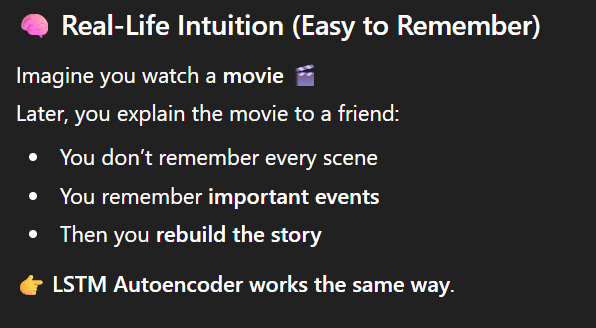

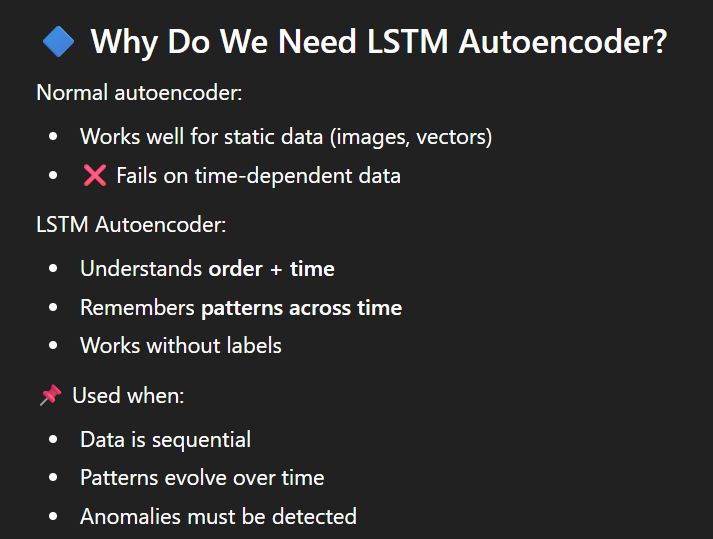

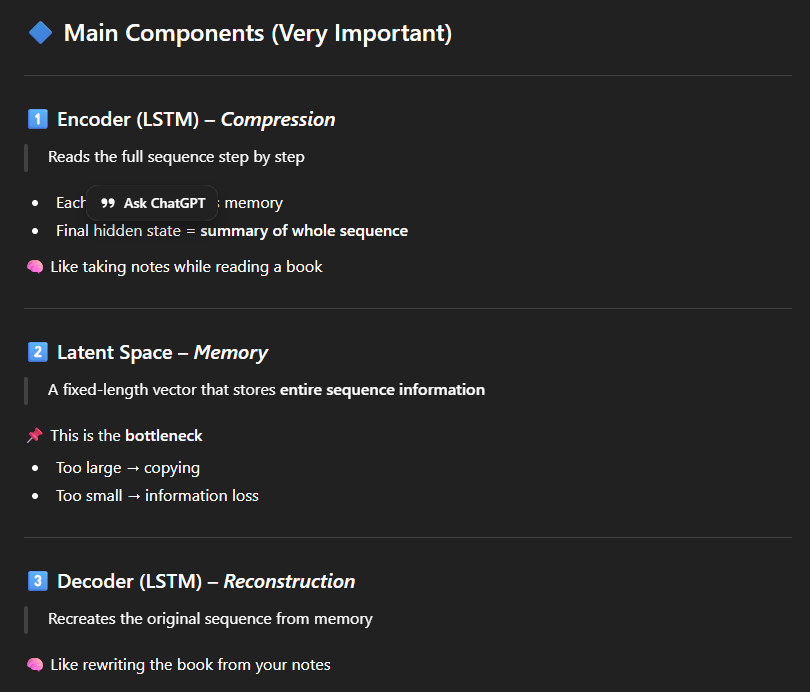

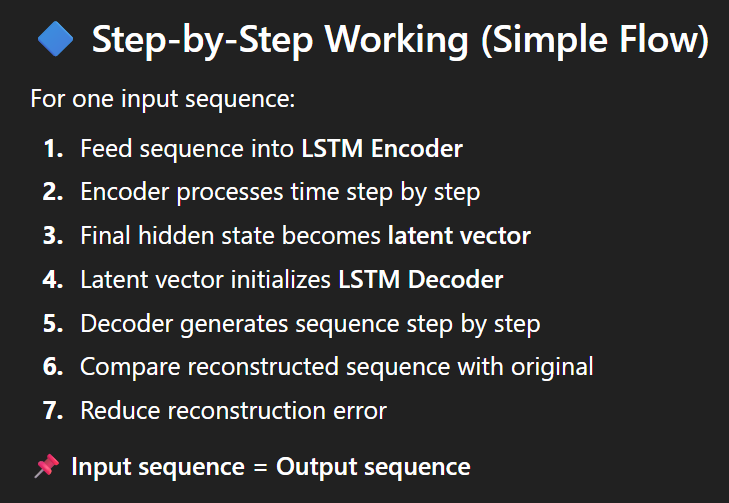

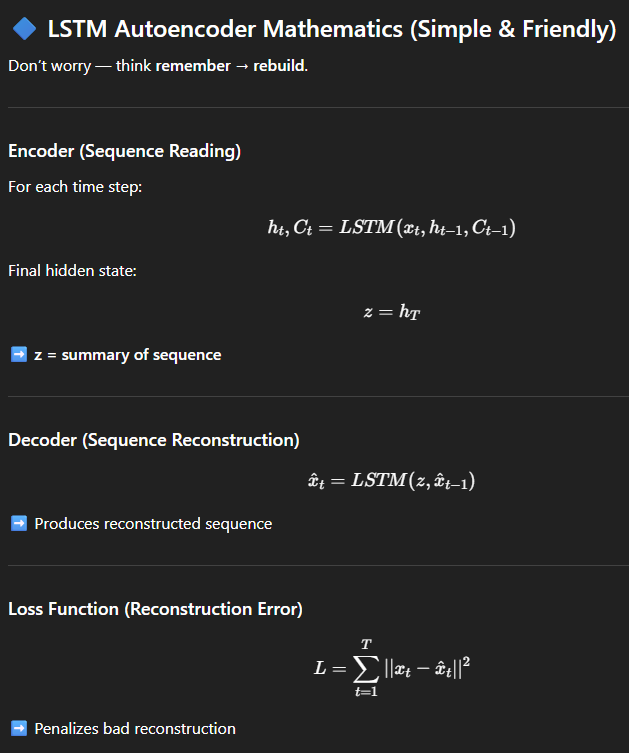

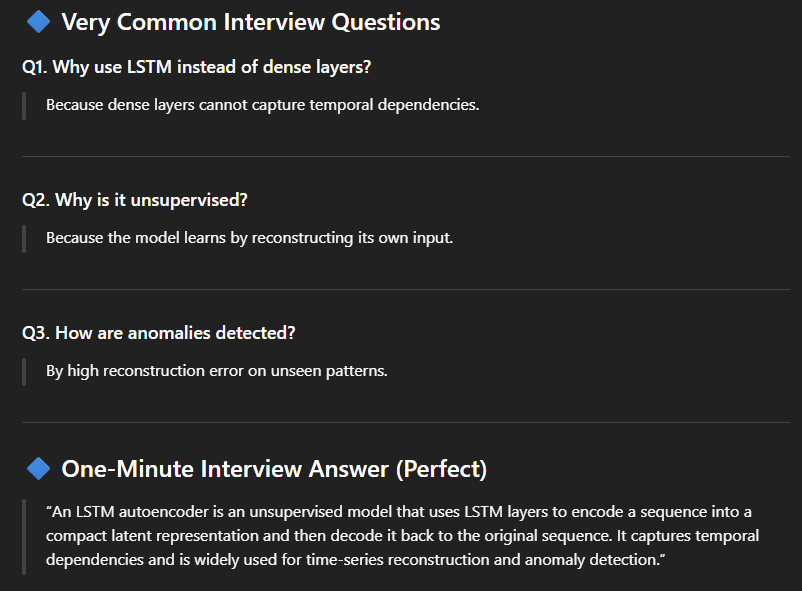

---

# Implementaion

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense,LSTM, RepeatVector, TimeDistributed

In [3]:
X = np.random.rand(1000, 10, 1)

In [ ]:
timesteps = X.shape[1]
features = X.shape[2]

inputs = Input(shape=(timesteps, features))

encoded = LSTM(64, activation='relu')(inputs)

In [ ]:
latent = RepeatVector(timesteps)(encoded)

In [ ]:
decoded = LSTM(64, activation='relu', return_sequences=True)(latent)
decoded = TimeDistributed(Dense(features))(decoded)

In [ ]:
lstm_autoencoder = Model(inputs, decoded)

In [8]:
lstm_autoencoder.compile(
    optimizer='adam',
    loss='mse'
)

In [9]:
lstm_autoencoder.fit(
    X, X,                     # input = output
    epochs=40,
    batch_size=32,
    validation_split=0.2
)


Epoch 1/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.1847 - val_loss: 0.1053
Epoch 2/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0989 - val_loss: 0.0921
Epoch 3/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0855 - val_loss: 0.0825
Epoch 4/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0791 - val_loss: 0.0767
Epoch 5/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0746 - val_loss: 0.0728
Epoch 6/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0719 - val_loss: 0.0704
Epoch 7/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0703 - val_loss: 0.0698
Epoch 8/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0692 - val_loss: 0.0686
Epoch 9/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0684 - val_loss: 0.0682
Epoch 10/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0679 - val_loss: 0.0673
Epoch 11/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0673 - val_loss: 0.0671
Epoch 12/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0669 - val